In [29]:
#Mount Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
#Check Correct Folder Name
import os

os.listdir("/content/drive/MyDrive")


['Colab Notebooks',
 'Screenshot_2021-03-06-17-30-27-715_com.whatsapp.jpg',
 'Screenshot_2021-03-06-17-30-33-901_com.whatsapp.jpg',
 'instagram_nixon_beats_155170779_443267250451009_7023479224551301946_n.mp4',
 '156570786_501997537466274_4310194010557896605_n.mp4',
 'ba42219fcd7140d79441784312df2bde.mp4',
 '157311186_244108640685853_2599902340998194058_n.mp4',
 'a1bc71b9476e438198ea5ca99c920ff8.mp4',
 '078008100a134e88a2272859de173c17.mp4',
 'e799018daf964a919815df3500391f9d.mp4',
 'c4d3dec81c1e43d99e75a5f7f56fd5ca.mp4',
 '14a1b680028142e08f6eb7aabb803fef.mp4',
 'Screenshot_2021-03-05-19-50-30-147_com.whatsapp.jpg',
 '966adbebc06b4e369c615f02a74a5fa6.mp4',
 '6c9ad2e214c54ed48626e1cb90872fa8.mp4',
 'Screenshot_2021-03-04-19-13-08-439_com.whatsapp.jpg',
 '7c73ff1777b741e1b24cb59f1917cc8a.mp4',
 'IMG-20210303-WA0014.jpg',
 'IMG-20210303-WA0013.jpg',
 'IMG-20210303-WA0012.jpg',
 'IMG-20210303-WA0010.jpg',
 'IMG-20210303-WA0009.jpg',
 'IMG-20210303-WA0008.jpg',
 'IMG_20201230_223347_440.jpg

In [3]:
#Copy Dataset to Colab (FAST)
import shutil

# CHANGE THIS to your exact folder name
src = "/content/drive/MyDrive/Dragon Fruit Maturity Detection and Quality Grading Dataset"

dst = "/content/dataset"

# Remove existing dataset if already copied
if os.path.exists(dst):
    shutil.rmtree(dst)

# Copy dataset
shutil.copytree(src, dst)

print("Dataset copied successfully!")

Dataset copied successfully!


In [4]:
#Verify Copy
os.listdir("/content/dataset")

['Dragon Fruit Maturity Detection and Quality Grading Dataset']

In [5]:
#CHECK TOP-LEVEL STRUCTURE
import os

os.listdir("/content/dataset")

['Dragon Fruit Maturity Detection and Quality Grading Dataset']

In [6]:
#EXPLORE DEEP STRUCTURE
for root, dirs, files in os.walk("/content/dataset"):
    print(f"{root} → {len(files)} files")

/content/dataset → 0 files
/content/dataset/Dragon Fruit Maturity Detection and Quality Grading Dataset → 2 files


In [11]:
#Locate ZIP FILES
import os

base_path = "/content/dataset"

for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.endswith(".zip"):
            print("ZIP found:", os.path.join(root, file))

ZIP found: /content/dataset/Dragon Fruit Maturity Detection and Quality Grading Dataset/Dragon Fruit Quality Grading Dataset.zip
ZIP found: /content/dataset/Dragon Fruit Maturity Detection and Quality Grading Dataset/Dragon Fruit Maturity Detection Dataset.zip


In [12]:
#EXTRACT ALL ZIPS
import zipfile

def extract_all_zips(path):
    for root, dirs, files in os.walk(path):
        for file in files:
            if file.endswith(".zip"):
                zip_path = os.path.join(root, file)
                extract_to = os.path.join(root, file[:-4])

                print("Extracting:", zip_path)

                with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                    zip_ref.extractall(extract_to)

extract_all_zips("/content/dataset")

Extracting: /content/dataset/Dragon Fruit Maturity Detection and Quality Grading Dataset/Dragon Fruit Quality Grading Dataset.zip
Extracting: /content/dataset/Dragon Fruit Maturity Detection and Quality Grading Dataset/Dragon Fruit Maturity Detection Dataset.zip


In [13]:
#VERIFY EXTRACTION
for root, dirs, files in os.walk("/content/dataset"):
    print(root, len(files))

/content/dataset 0
/content/dataset/Dragon Fruit Maturity Detection and Quality Grading Dataset 2
/content/dataset/Dragon Fruit Maturity Detection and Quality Grading Dataset/Dragon Fruit Maturity Detection Dataset 0
/content/dataset/Dragon Fruit Maturity Detection and Quality Grading Dataset/Dragon Fruit Maturity Detection Dataset/Dragon Fruit Maturity Detection Dataset 0
/content/dataset/Dragon Fruit Maturity Detection and Quality Grading Dataset/Dragon Fruit Maturity Detection Dataset/Dragon Fruit Maturity Detection Dataset/Original Dataset 0
/content/dataset/Dragon Fruit Maturity Detection and Quality Grading Dataset/Dragon Fruit Maturity Detection Dataset/Dragon Fruit Maturity Detection Dataset/Original Dataset/Immature Dragon Fruit 1241
/content/dataset/Dragon Fruit Maturity Detection and Quality Grading Dataset/Dragon Fruit Maturity Detection Dataset/Dragon Fruit Maturity Detection Dataset/Original Dataset/Mature Dragon Fruit 886
/content/dataset/Dragon Fruit Maturity Detection 

In [14]:
#Check Actual Folder Names
import os

os.listdir("/content/dataset")

['Dragon Fruit Maturity Detection and Quality Grading Dataset']

In [15]:
for folder in os.listdir("/content/dataset"):
    print(folder)
    print(os.listdir(f"/content/dataset/{folder}"))

Dragon Fruit Maturity Detection and Quality Grading Dataset
['Dragon Fruit Quality Grading Dataset.zip', 'Dragon Fruit Maturity Detection Dataset', 'Dragon Fruit Maturity Detection Dataset.zip', 'Dragon Fruit Quality Grading Dataset']


In [22]:
#Maturity Dataset - Final Path
maturity_path = "/content/dataset/Dragon Fruit Maturity Detection and Quality Grading Dataset/Dragon Fruit Maturity Detection Dataset/Dragon Fruit Maturity Detection Dataset/Original Dataset"

In [23]:
#Quality Dataset - Final Path
quality_path = "/content/dataset/Dragon Fruit Maturity Detection and Quality Grading Dataset/Dragon Fruit Quality Grading Dataset/Dragon Fruit Quality Grading Dataset/Original Dataset"

In [24]:
#VERIFY PATHS
print("Maturity classes:", os.listdir(maturity_path))
print("Quality classes:", os.listdir(quality_path))

Maturity classes: ['Immature Dragon Fruit', 'Mature Dragon Fruit']
Quality classes: ['Defect Dragon Fruit', 'Fresh Dragon Fruit']


In [25]:
#COUNT IMAGES
def count_images(path):
    counts = {}
    for cls in os.listdir(path):
        cls_path = os.path.join(path, cls)
        if os.path.isdir(cls_path):
            counts[cls] = len(os.listdir(cls_path))
    return counts

print("Maturity:", count_images(maturity_path))
print("Quality:", count_images(quality_path))

Maturity: {'Immature Dragon Fruit': 1241, 'Mature Dragon Fruit': 886}
Quality: {'Defect Dragon Fruit': 754, 'Fresh Dragon Fruit': 898}


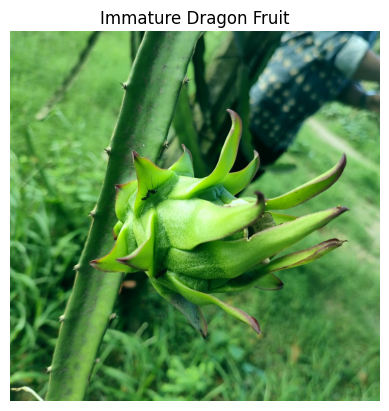

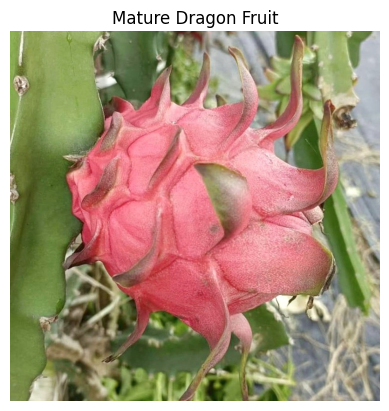

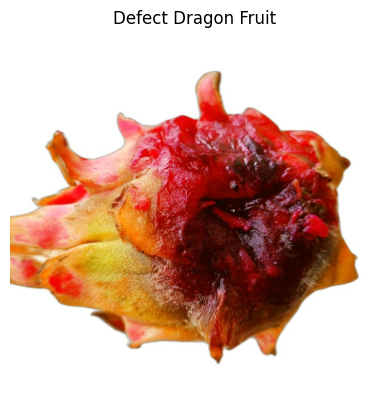

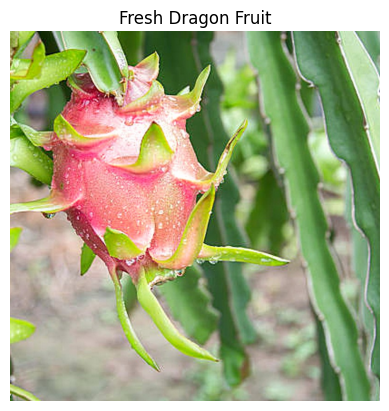

In [26]:
#VISUALIZE and Obtain Samples of each classified section
import cv2
import matplotlib.pyplot as plt
import random

def show_samples(path):
    for cls in os.listdir(path):
        cls_path = os.path.join(path, cls)
        img_name = random.choice(os.listdir(cls_path))
        img_path = os.path.join(cls_path, img_name)

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.imshow(img)
        plt.title(cls)
        plt.axis("off")
        plt.show()

show_samples(maturity_path)
show_samples(quality_path)

In [27]:
# Data Cleaning
from PIL import Image

def clean_dataset(path):
    for cls in os.listdir(path):
        cls_path = os.path.join(path, cls)
        for file in os.listdir(cls_path):
            file_path = os.path.join(cls_path, file)
            try:
                img = Image.open(file_path)
                img.verify()
            except:
                os.remove(file_path)

clean_dataset(maturity_path)
clean_dataset(quality_path)

print("Dataset cleaned!")

Dataset cleaned!


In [28]:
# Final report
print("Final Counts:")
print("Maturity:", count_images(maturity_path))
print("Quality:", count_images(quality_path))

Final Counts:
Maturity: {'Immature Dragon Fruit': 1241, 'Mature Dragon Fruit': 886}
Quality: {'Defect Dragon Fruit': 754, 'Fresh Dragon Fruit': 898}


In [30]:
#train-validation-test split of Dataset
import os
import shutil
import random

def split_dataset(source_dir, target_dir, train=0.7, val=0.2, test=0.1):

    for cls in os.listdir(source_dir):
        cls_path = os.path.join(source_dir, cls)
        files = os.listdir(cls_path)
        random.shuffle(files)

        train_end = int(train * len(files))
        val_end = int((train + val) * len(files))

        splits = {
            "train": files[:train_end],
            "val": files[train_end:val_end],
            "test": files[val_end:]
        }

        for split in splits:
            split_path = os.path.join(target_dir, split, cls)
            os.makedirs(split_path, exist_ok=True)

            for file in splits[split]:
                src = os.path.join(cls_path, file)
                dst = os.path.join(split_path, file)
                shutil.copy(src, dst)

# Create split folder
split_root = "/content/data"

split_dataset(maturity_path, split_root)

In [31]:
split_root = "/content/drive/MyDrive/data/maturity"
split_dataset(maturity_path, split_root)